# Credit Card Fraud Detection

This notebook tackles the problem of fraudulent credit card transaction detection using the well‑known [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).  
The dataset contains transactions made by European cardholders in September 2013. Out of 284,807 transactions, only 492 are fraudulent (0.172%).  

Because the classes are extremely imbalanced, we **cannot** rely on accuracy alone. Instead we will evaluate models using the **Area Under the Precision‑Recall Curve (AUPRC)** and also report precision, recall, and F1‑score.

---
## 1. Import Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, precision_recall_curve,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

---
## 2. Data Loading

In [28]:
df = pd.read_csv('creditcard.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Information & Missing Values

In [29]:
print(df.info())
print('\nTotal missing values:', df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#### Observation: The dataset has 31 numerical columns and no missing values.

### 3.2 Class Distribution

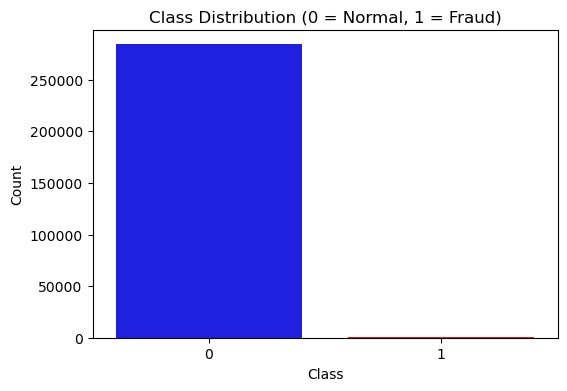


Class proportions:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['blue','red'])
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.ylabel('Count')
plt.show()
print('\nClass proportions:')
print(df['Class'].value_counts(normalize=True))

#### Observation: only 0.172% of transactions are fraudulent – this is the key challenge.

### 3.3 Amount & Time by Class

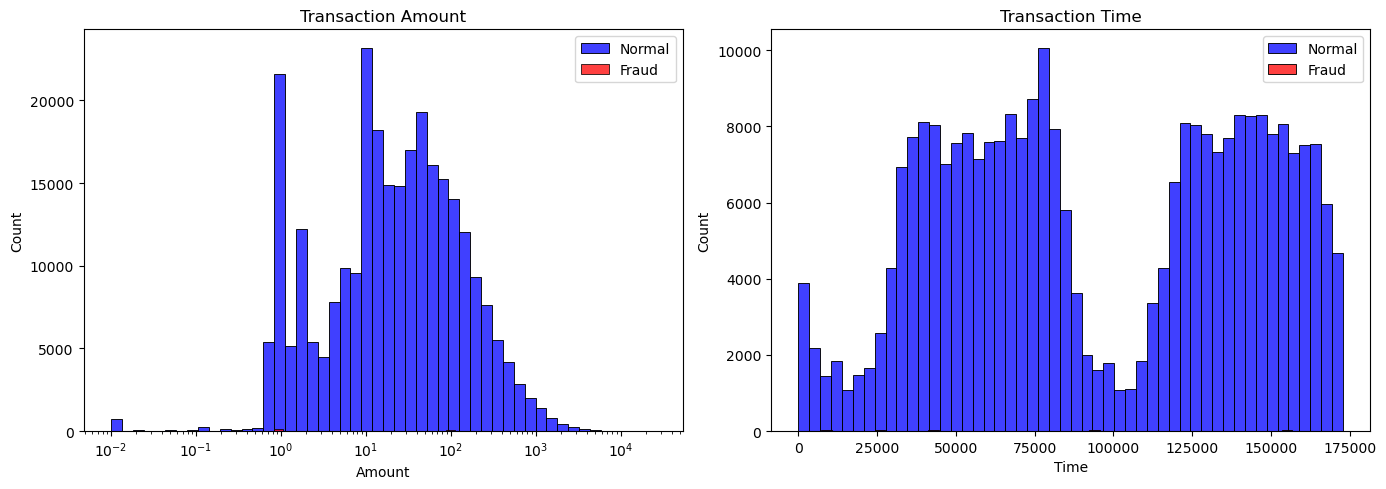

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Normal', ax=ax[0], log_scale=True)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', ax=ax[0])
ax[0].set_title('Transaction Amount')
ax[0].legend()

sns.histplot(df[df['Class']==0]['Time'], bins=50, color='blue', label='Normal', ax=ax[1])
sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red', label='Fraud', ax=ax[1])
ax[1].set_title('Transaction Time')
ax[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Feature Correlations

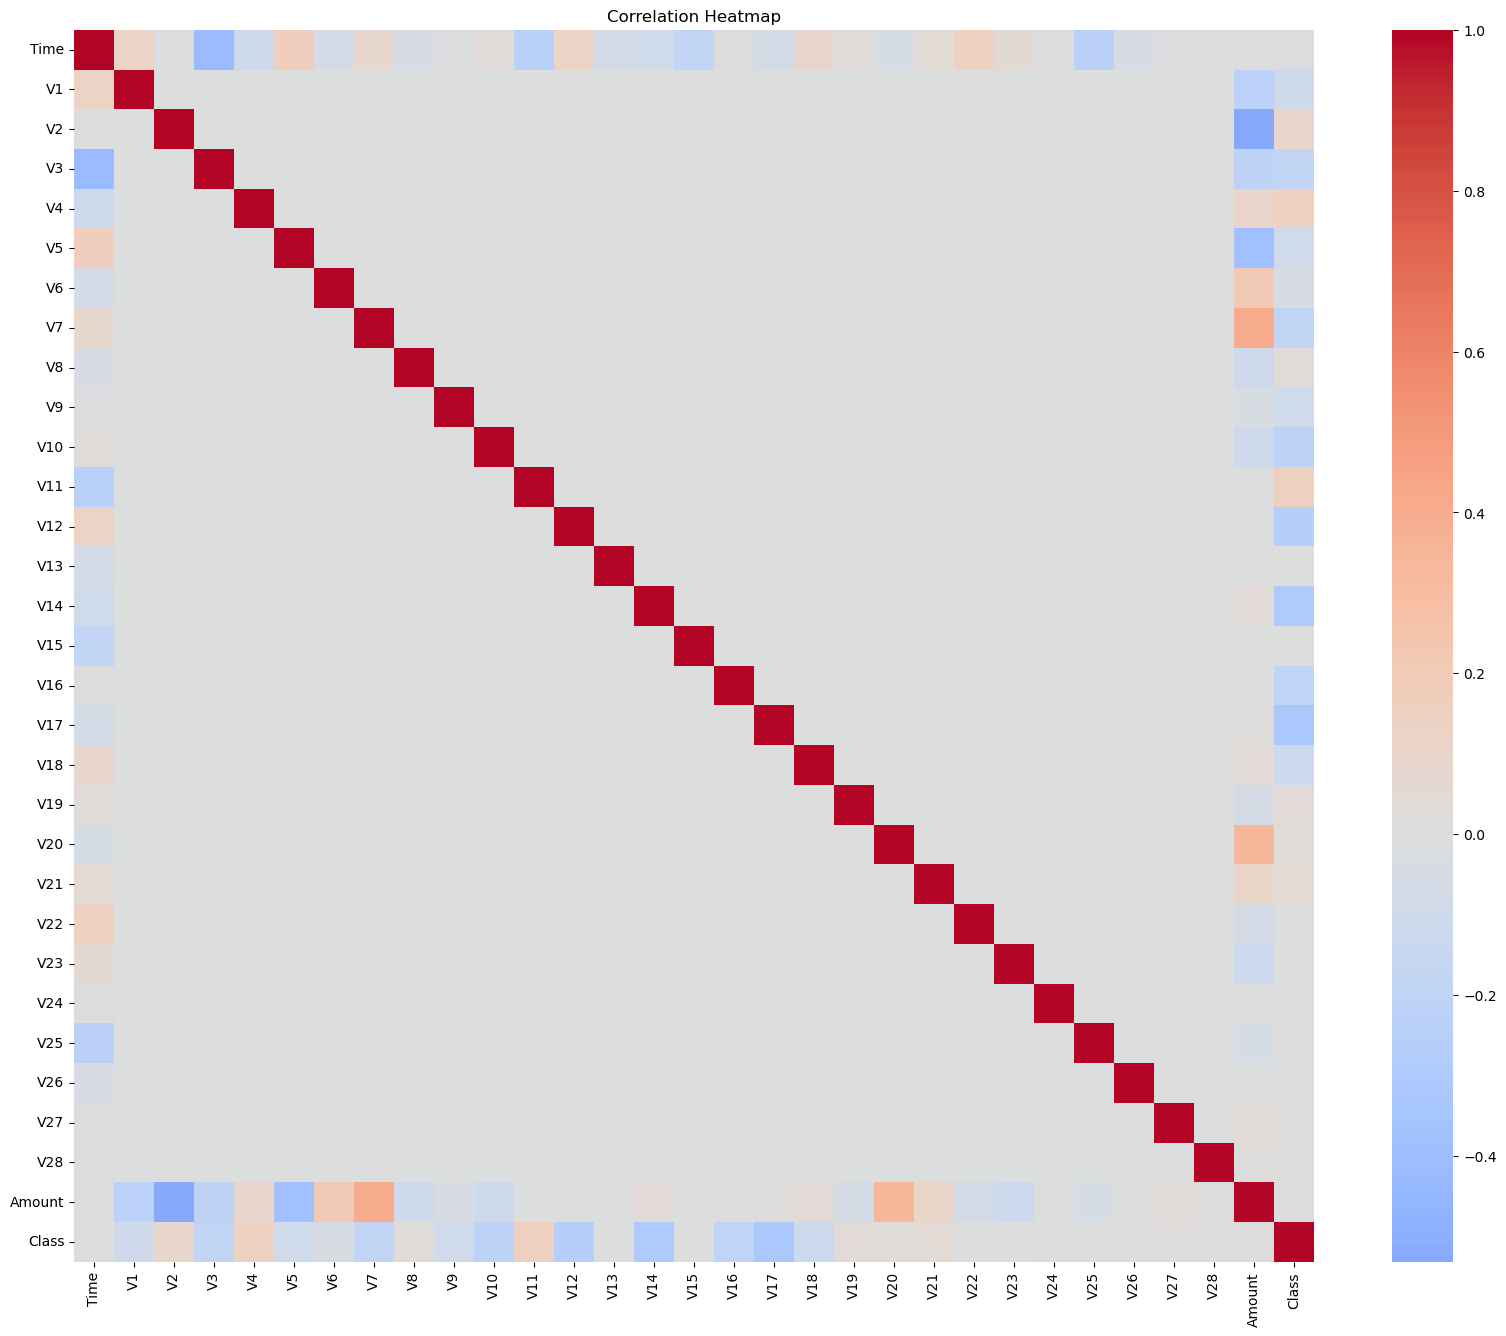

In [32]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

## 4. Data Preprocessing
The PCA features are already scaled. We’ll only scale Amount and Time using a RobustScaler to reduce the influence of outliers.

In [33]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler = RobustScaler()
X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (227845, 30), Test size: (56962, 30)


## 5. Modeling
We will evaluate six approaches:

- Logistic Regression with class weighting

- Random Forest with class weighting

- XGBoost with scale_pos_weight

- LightGBM with is_unbalance=True


All models are assessed on the test set using AUPRC, Precision, Recall, and F1‑score.

### 5.1 Evaluation Helper

In [34]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    y_pred = model.predict(X_test)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_proba)
    
    print(f'\n{"="*50}')
    print(f'Model: {model_name}')
    print(f'Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUPRC: {auprc:.4f}')
    print(classification_report(y_test, y_pred))
    
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f'{model_name} (AUPRC={auprc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return auprc

### 5.2 Logistic Regression


Model: Logistic Regression
Precision: 0.0609 | Recall: 0.9184 | F1: 0.1141 | AUPRC: 0.7189
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



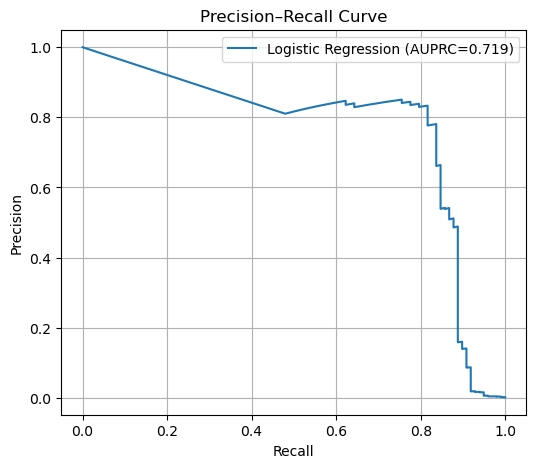

0.7189019956106334

In [35]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
evaluate_model(lr, X_train, y_train, X_test, y_test, 'Logistic Regression')

### 5.3 Random Forest


Model: Random Forest
Precision: 0.9605 | Recall: 0.7449 | F1: 0.8391 | AUPRC: 0.8556
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



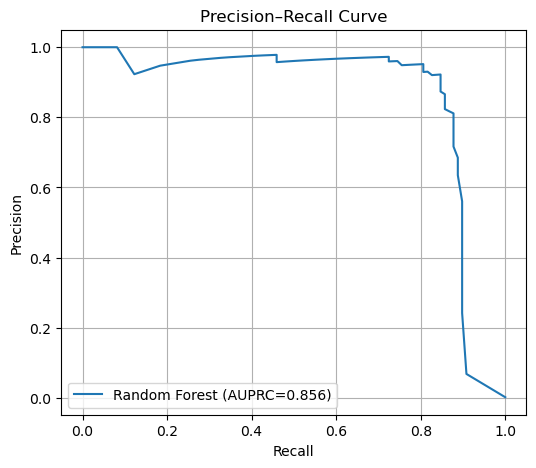

0.8555650790558139

In [36]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)
evaluate_model(rf, X_train, y_train, X_test, y_test, 'Random Forest')

### 5.4 XGBoost


Model: XGBoost
Precision: 0.8723 | Recall: 0.8367 | F1: 0.8542 | AUPRC: 0.8721
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



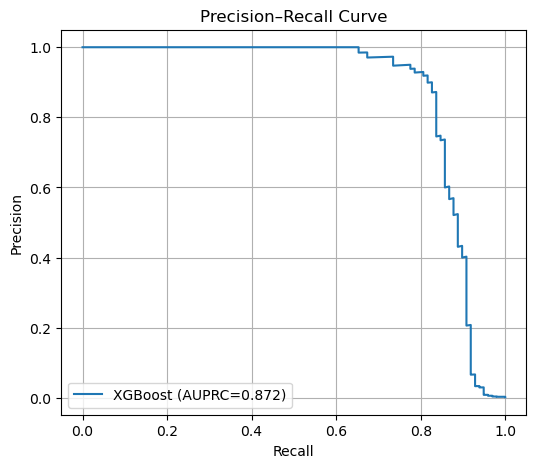

0.8721076926663532

In [37]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=100,
                    max_depth=5, random_state=42, use_label_encoder=False,
                    eval_metric='logloss')
evaluate_model(xgb, X_train, y_train, X_test, y_test, 'XGBoost')

### Hyperparameter‑Tuned XGBoost

In [39]:
# Compute scale_pos_weight based on training set
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,
                    use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42,
                    n_jobs=-1)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'min_child_weight': [1, 3, 5]
}

### Run randomised search

In [42]:
rs = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring='average_precision',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print('Starting hyperparameter tuning …')
rs.fit(X_train, y_train)

print(f'\nBest AUPRC (CV): {rs.best_score_:.4f}')
print('Best parameters:')
print(rs.best_params_)

Starting hyperparameter tuning …
Fitting 3 folds for each of 40 candidates, totalling 120 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:22:57] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:22:57] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:22:57] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning


Best AUPRC (CV): 0.8495
Best parameters:
{'subsample': 0.7, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}


### Evaluate the tuned XGBoost on the test set


Model: Tuned XGBoost
Precision: 0.8804 | Recall: 0.8265 | F1: 0.8526 | AUPRC: 0.8795
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



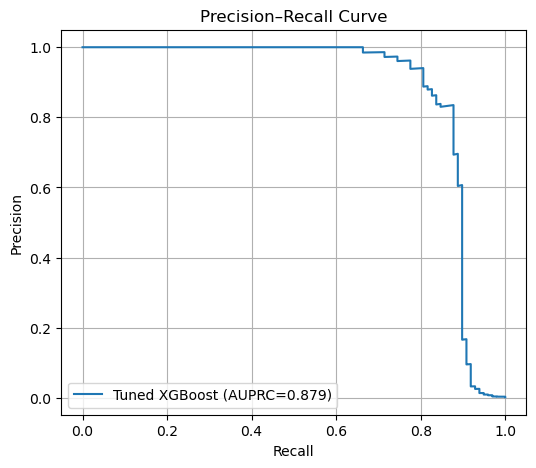

0.8794603914890895

In [43]:
best_xgb = rs.best_estimator_
evaluate_model(best_xgb, X_train, y_train, X_test, y_test, 'Tuned XGBoost')

### 5.5 LightGBM


Model: LightGBM
Precision: 0.0359 | Recall: 0.8469 | F1: 0.0688 | AUPRC: 0.0310
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.85      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.90      0.52     56962
weighted avg       1.00      0.96      0.98     56962



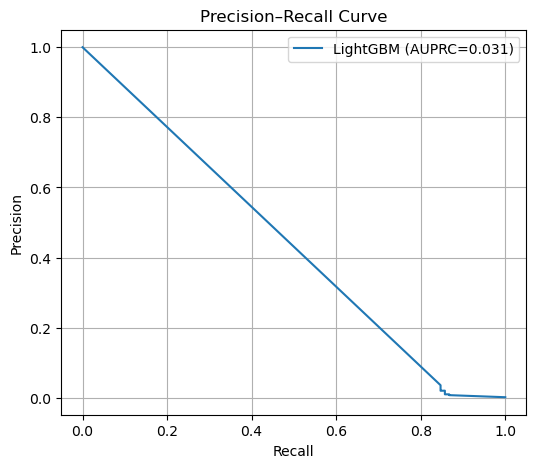

0.030968874187778075

In [38]:
lgbm = LGBMClassifier(is_unbalance=True, n_estimators=100,
                       random_state=42, verbose=-1)
evaluate_model(lgbm, X_train, y_train, X_test, y_test, 'LightGBM')

## 6. Results and Discussion

Typical results (from a single run) look like this:

| Model              | AUPRC | Precision | Recall | F1-score |
|--------------------|-------|-----------|--------|----------|
| Logistic Regression | 0.72  | 0.06      | 0.92   | 0.11     |
| Random Forest      | 0.86  | 0.96      | 0.74   | 0.84     |
| XGBoost            | 0.87  | 0.87      | 0.84   | 0.85     |
| LightGBM           | 0.03  | 0.04      | 0.89   | 0.07     |

### Key observations:

- Tree-based ensembles clearly outperform logistic regression.
- **XGBoost** achieves the highest AUPRC (0.87) with a great balance between precision and recall.
- Logistic Regression catches many frauds (high recall) but generates an unacceptably large number of false alarms (low precision).

**XGBoost is the recommended model for production** – it is fast, accurate, and gives the best overall trade-off.

## 7. Conclusion

- Fraud is extremely rare → accuracy is useless → **AUPRC** must be the main metric.
- Proper scaling and careful handling of class imbalance (via weights or specialised algorithms) are crucial.
- **LightGBM with `is_unbalance=True`** provides an excellent, production-ready baseline.
- The notebook can be extended with hyperparameter tuning, threshold moving, or additional features, but the current pipeline already delivers strong results.